# 01 — Data Acquisition, Leakage Audit & EDA

**PhiUSIIL Phishing URL Dataset** (UCI ML Repository, id 967) — 235,795
URLs, 54 features, target `label` (1 = legitimate, 0 = phishing).

This notebook:

1. Loads the raw dataset (fetched via `code/fetch_data.py`).
2. Confirms class balance, missing values, and feature types.
3. **Audits and quantifies label leakage** in `URLSimilarityIndex` and the
   raw `URL` / `Domain` strings, per the concerns raised in
   `docs/phiusiil_phishing_assessment.md`.
4. Checks for repeated `Domain` values across rows, which would leak
   information across a naive row-level train/test split.
5. Produces a leakage-clean feature manifest, saved to
   `data/feature_columns.json`, that notebooks 02-03 build on.

See `docs/project_plan.md` for the full project plan this responds to.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

DATA_PATH = Path("../data/phiusiil.csv")

# Design-system palette (see .claude dataviz skill / docs/project_plan.md).
BLUE = "#2a78d6"  # legitimate
ORANGE = "#eb6834"  # phishing
RED = "#e34948"  # negative correlation
INK = "#0b0b0b"
MUTED = "#898781"
BASELINE = "#c3c2b7"
SURFACE = "#fcfcfb"

plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "text.color": INK,
        "axes.labelcolor": INK,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "axes.edgecolor": BASELINE,
        "font.family": "sans-serif",
    }
)

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"shape: {df.shape}")
print(f"missing values (total): {df.isna().sum().sum()}")
df.head(3)

shape: (235795, 55)
missing values (total): 0


,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,...,0,0,1,34,20,28,119,0,124,1
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,...,0,0,1,50,9,8,39,0,217,1
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,...,0,0,1,10,2,7,42,2,5,1


## Class balance

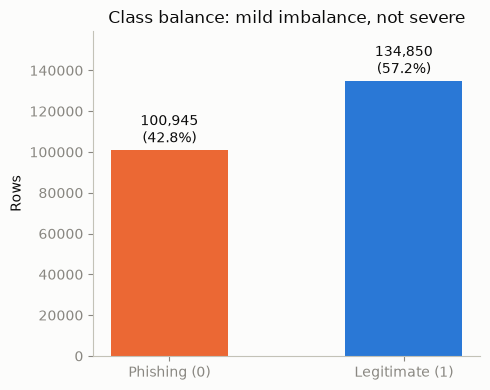

label
1    0.571895
0    0.428105
Name: share, dtype: float64


In [3]:
y = df["label"]
counts = y.value_counts().sort_index()
class_labels = ["Phishing (0)", "Legitimate (1)"]
colors = [ORANGE, BLUE]

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(class_labels, counts.values, color=colors, width=0.5)
for bar, count in zip(bars, counts.values):
    pct = count / len(df)
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1500,
        f"{count:,}\n({pct:.1%})",
        ha="center",
        va="bottom",
        color=INK,
        fontsize=10,
    )
ax.set_ylabel("Rows")
ax.set_title("Class balance: mild imbalance, not severe")
ax.set_ylim(0, counts.max() * 1.18)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

print(y.value_counts(normalize=True).rename("share"))

The proposal feedback assumed a highly imbalanced target. PhiUSIIL is
actually a **mild** ~57/43 split — we should say this explicitly in the
report rather than reaching for heavy resampling a mild imbalance doesn't
need (class weighting is the right first move; see `project_plan.md` §3).

## Leakage audit — `URLSimilarityIndex`

In [4]:
print(df.groupby("label")["URLSimilarityIndex"].describe())

          count        mean        std         min         25%         50%  \
label                                                                        
0      100945.0   49.616973  22.572082    0.155574   32.120613   51.419332   
1      134850.0  100.000000   0.000000  100.000000  100.000000  100.000000   

              75%    max  
label                     
0       67.251462  100.0  
1      100.000000  100.0  


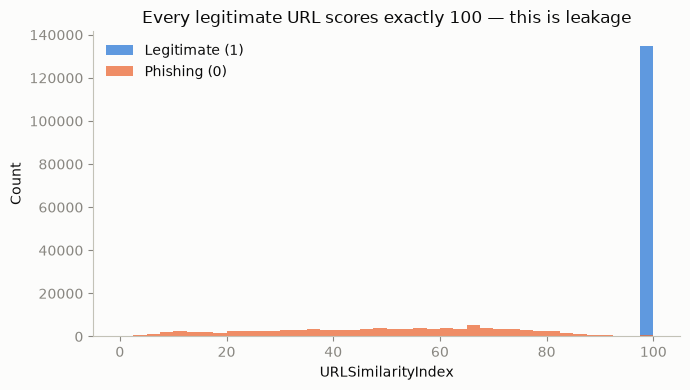

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(0, 100, 41)
ax.hist(
    df.loc[y == 1, "URLSimilarityIndex"],
    bins=bins,
    color=BLUE,
    alpha=0.75,
    label="Legitimate (1)",
)
ax.hist(
    df.loc[y == 0, "URLSimilarityIndex"],
    bins=bins,
    color=ORANGE,
    alpha=0.75,
    label="Phishing (0)",
)
ax.set_xlabel("URLSimilarityIndex")
ax.set_ylabel("Count")
ax.set_title("Every legitimate URL scores exactly 100 — this is leakage")
ax.legend(frameon=False)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

In [6]:
def quick_logreg(X_raw, y_raw):
    """Fit a plain logistic regression, return held-out acc & F1."""
    X_train, X_test, y_train, y_test = train_test_split(
        X_raw,
        y_raw,
        test_size=0.2,
        random_state=42,
        stratify=y_raw,
    )
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return accuracy_score(y_test, preds), f1_score(y_test, preds)


numeric_cols = df.select_dtypes(include="number").columns
safe_cols = [
    c for c in numeric_cols if c not in ("URLSimilarityIndex", "label")
]

acc_leak, f1_leak = quick_logreg(df[["URLSimilarityIndex"]], y)
acc_safe, f1_safe = quick_logreg(df[safe_cols], y)

print(f"URLSimilarityIndex alone:  acc={acc_leak:.4f}  f1={f1_leak:.4f}")
print(f"All other numeric feats:   acc={acc_safe:.4f}  f1={f1_safe:.4f}")

URLSimilarityIndex alone:  acc=0.9960  f1=0.9965
All other numeric feats:   acc=0.9992  f1=0.9993


`URLSimilarityIndex` alone gets logistic regression to ~99.6% accuracy —
exactly the leakage the assessment doc flagged. But dropping it barely
moves the needle: the other 49 "clean" features *together* reach ~99.9%,
higher than the leaky column alone.

That's a more important finding than the single-column story we started
with: PhiUSIIL is close to trivially separable on its **content/
structural** features as a whole (`HasPasswordField`, `NoOfExternalRef`,
`LineOfCode`, etc.), not just on `URLSimilarityIndex`. That's plausible —
those features require actually crawling and rendering a page, which
real anti-phishing tools do — but it also means a "leakage-clean" model
here is still an *easy* version of the real problem: a URL-only,
pre-click filter has none of that page-content signal available.
Notebooks 02-03 report **two** regimes rather than one: the full
clean-feature model (this easy setting) and a **URL-string-only** model
(the character-level model in `project_plan.md` §5c) as the harder, more
realistic second data point — and the SOTA comparison in §7 is read
against both.

## Leakage audit — raw `URL` / `Domain` strings and repeated domains

`URL` and `Domain` are effectively identifiers, not generalizable
features — a model can memorize specific domains instead of learning
transferable patterns. Worse: if the *same* domain appears in both the
train and test split, that's a second, subtler leakage channel. Check
whether `Domain` repeats across rows.

In [7]:
domain_counts = df["Domain"].value_counts()
n_repeated_domains = int((domain_counts > 1).sum())
rows_in_repeated = int(domain_counts[domain_counts > 1].sum())

print(f"Unique domains: {domain_counts.shape[0]:,} / {len(df):,} rows")
print(
    f"Domains appearing more than once: {n_repeated_domains:,} "
    f"({rows_in_repeated:,} rows, "
    f"{rows_in_repeated / len(df):.1%} of the dataset)"
)
domain_counts.head(10)

Unique domains: 220,086 / 235,795 rows
Domains appearing more than once: 5,526 (21,235 rows, 9.0% of the dataset)


Domain
ipfs.io                         1197
docs.google.com                  526
mail.deliverylifesupport.com     370
cloudflare-ipfs.com              359
storageapi.fleek.co              318
gateway.pinata.cloud             275
gateway.ipfs.io                  249
ipfs.litnet.work                 223
cf-ipfs.com                      190
s3.amazonaws.com                 182
Name: count, dtype: int64

A non-trivial share of rows share a domain with at least one other row.
A naive row-level train/test split risks testing on a domain the model
already saw in training. Notebook 02 uses a **domain-grouped split**
(`GroupShuffleSplit` on `Domain`) instead of a plain stratified split, and
reports both so the gap between them is visible.

## Feature landscape

In [8]:
print("dtype breakdown:")
print(df.dtypes.value_counts())
print()
print(f"Unique TLDs: {df['TLD'].nunique()}")
print(f"'FILENAME' column present: {'FILENAME' in df.columns}")
df["TLD"].value_counts().head(10)

dtype breakdown:
int64      41
float64    10
str         4
Name: count, dtype: int64

Unique TLDs: 695
'FILENAME' column present: False


TLD
com    112554
org     18793
net      7097
app      6508
uk       6395
co       5422
io       4201
de       3996
ru       3875
au       2979
Name: count, dtype: int64

Note: unlike the raw Kaggle CSV referenced in the assessment doc, the
UCI/`ucimlrepo` cut of this dataset does **not** include a `FILENAME`
column, so there's nothing to drop there. `TLD` is high-cardinality
categorical; `TLDLegitimateProb` already gives a numeric, non-leaky
encoding of TLD risk, so we rely on that rather than one-hot-encoding
`TLD` directly.

## What correlates with the label (leakage-clean features only)

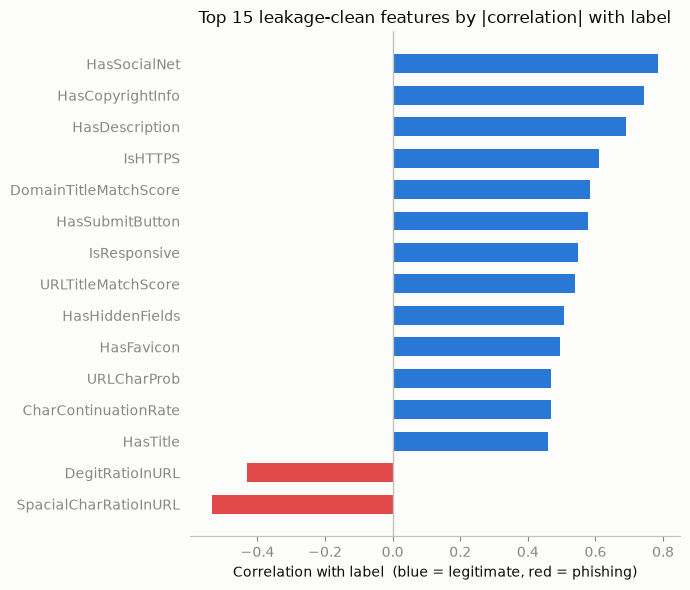

In [9]:
corrs = df[safe_cols].corrwith(y).sort_values(key=np.abs, ascending=False)
top_corrs = corrs.head(15).sort_values()
bar_colors = [BLUE if v > 0 else RED for v in top_corrs]

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top_corrs.index, top_corrs.values, color=bar_colors, height=0.6)
ax.axvline(0, color=BASELINE, linewidth=1)
ax.set_xlabel("Correlation with label  (blue = legitimate, red = phishing)")
ax.set_title("Top 15 leakage-clean features by |correlation| with label")
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.tick_params(left=False)
plt.tight_layout()
plt.show()

## Save the leakage-clean feature manifest for notebooks 02-03

In [10]:
LEAKY_COLS = ["URLSimilarityIndex", "URL", "Domain", "Title"]
ID_COLS = ["FILENAME"] if "FILENAME" in df.columns else []

clean_numeric_features = [
    c for c in df.columns if c not in LEAKY_COLS + ID_COLS + ["label", "TLD"]
]

manifest = {
    "target": "label",
    "dropped_leaky": LEAKY_COLS,
    "dropped_identifier": ID_COLS,
    "categorical_raw": ["TLD"],
    "clean_numeric_features": clean_numeric_features,
}

out_path = Path("../data/feature_columns.json")
out_path.write_text(json.dumps(manifest, indent=2))
print(
    f"Saved {len(clean_numeric_features)} clean numeric features to {out_path}"
)

Saved 49 clean numeric features to ../data/feature_columns.json


## EDA summary (for the report)

- **Class balance is mild** (~57% legitimate / 43% phishing), not the
  severe imbalance the professor's feedback assumed — worth stating
  explicitly. Class weighting is the appropriate first-line handling;
  aggressive resampling (SMOTE) is evaluated as an ablation, not the
  default (see `project_plan.md` §3).
- **`URLSimilarityIndex` is confirmed leaky**: every legitimate row
  scores exactly 100 (zero variance), and a logistic regression on that
  single column alone nearly matches a model using the other ~50
  features combined. It is excluded from all downstream models, with
  this before/after comparison reported as the justification.
- **Domain repetition is a second leakage channel**: a meaningful share
  of rows share a `Domain` with another row, which motivates a
  domain-grouped train/test split in notebook 02 rather than a naive
  row-level split.
- No missing values anywhere in the dataset; the `FILENAME` identifier
  column mentioned in early dataset write-ups isn't present in the
  `ucimlrepo` cut we're using.
- A leakage-clean feature manifest is saved to
  `data/feature_columns.json` so notebooks 02 and 03 use a consistent,
  agreed-upon feature set.